# Investigate Enhancer Single Cell Expression

From the previous analysis we have everything ready:

1. CBC (DNA) x cellBC Table
2. EBC (RNA) x cellBC Table
3. Annotated `adata` object

Now it's time to put things together and to quantitatively see where the enhancers are being expressed, on a single-cell level.

In [1]:
import scanpy as sc
import anndata as ad
import skimage
import seaborn as sns
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

# Import Datasets

In [2]:
adata = sc.read_h5ad('../6-grammar_final/JCF-HT_annotated.h5ad')

In [3]:
# Drop the Unknown cells as they are not helpful
adata = adata[adata.obs['updated_label']!='Unknown']

In [4]:
adata

View of AnnData object with n_obs × n_vars = 16929 × 14950
    obs: 'sample', 'n_genes_by_counts', 'total_counts', 'total_counts_mt', 'pct_counts_mt', 'n_genes', 'n_counts', 'doublet_score', 'predicted_doublet', 'leiden_res0_25', 'leiden_res0_5', 'leiden_res1', 'leiden_res3', 'celltype', 'updated_label', 'col_celltype', 'cellBC'
    var: 'mt', 'n_cells_by_counts', 'mean_counts', 'pct_dropout_by_counts', 'total_counts', 'n_cells', 'KH', 'Unique name (used in some papers)', 'Human homolog', 'Gene Name', 'highly_variable', 'means', 'dispersions', 'dispersions_norm', 'highly_variable_nbatches', 'highly_variable_intersection', 'mean', 'std'
    uns: 'dendrogram_leiden_res1', 'hvg', 'leiden_res0_25', 'leiden_res0_25_colors', 'leiden_res0_5', 'leiden_res0_5_colors', 'leiden_res1', 'leiden_res1_colors', 'leiden_res3', 'leiden_res3_colors', 'log1p', 'neighbors', 'pca', 'predicted_doublet_colors', 'sample_colors', 'scrublet', 'umap', 'updated_label_colors'
    obsm: 'X_pca', 'X_umap'
    varm: '

In [5]:
df1 = adata.obs[adata.obs['sample']=='JCF-1']
df2 = adata.obs[adata.obs['sample']=='JCF-2']
df3 = adata.obs[adata.obs['sample']=='JCF-3']

In [6]:
ebc1 = pd.read_csv('../6-grammar_final/JCF-MPRA-1.csv', index_col = 0)
ebc2 = pd.read_csv('../6-grammar_final/JCF-MPRA-2.csv', index_col = 0)
ebc3 = pd.read_csv('../6-grammar_final/JCF-MPRA-3.csv', index_col = 0)

In [7]:
cbc1 = pd.read_csv('../6-grammar_final/JCF-CBC-1.csv', index_col = 0)
cbc2 = pd.read_csv('../6-grammar_final/JCF-CBC-2.csv', index_col = 0)
cbc3 = pd.read_csv('../6-grammar_final/JCF-CBC-3.csv', index_col = 0)

In [2]:
lookup = pd.read_csv("../6-grammar_final/refs/enhancer_ebc_cbc_lookup.csv")

In [9]:
lookup.head()

,old_enhancer_id,Enhancer variant name,Enhancer Sequence,ebc,cbc,label_control,label_test,bin-anno,syntax-score,num-syntax-motifs,note,enhancer_id,outdated_enhancer_id
0,OSL10,OSL10_1,TGCTCACTTCCGTGTTATCTCTTTCGAAAAGATAGGCATCTGAAGC...,AATCAGTGTCGATCACTTAGCAGAATCAAC,GACACGCTCACGCTGTCCCAGACCC,Inert Zero,NaN,Moderate,3,2,NaN,ORL10,ORL10
1,OSL10,OSL10_2,TGCTCACTTCCGTGTTATCTCTTTCGAAAAGATAGGCATCTGAAGC...,TGAGGTGGTCCATGGTAATCGCTGCGATGT,CACGGGAGCCATGGGCCTGCCTTTC,Inert Zero,NaN,Moderate,3,2,NaN,ORL10,ORL10
2,OSL10,OSL10_3,TGCTCACTTCCGTGTTATCTCTTTCGAAAAGATAGGCATCTGAAGC...,CATGCTTGGTCCCAATACAAGGCTATGGTC,GAGAGTTCAATAATTAACCAGGGCC,Inert Zero,NaN,Moderate,3,2,NaN,ORL10,ORL10
3,OSL10,OSL10_4,TGCTCACTTCCGTGTTATCTCTTTCGAAAAGATAGGCATCTGAAGC...,TCTTGCCCCTTCACTGCCTCCTATAACCGG,GAACCTGGAGTAGCCTCCGAGTAAG,Inert Zero,NaN,Moderate,3,2,NaN,ORL10,ORL10
4,OSL10,OSL10_5,TGCTCACTTCCGTGTTATCTCTTTCGAAAAGATAGGCATCTGAAGC...,CGAGGACTAGACACAGACTCTGTAAGACGG,GATTCTATAGTAAGGGCTTAGCCGA,Inert Zero,NaN,Moderate,3,2,NaN,ORL10,ORL10


In [10]:
ebc2bc = dict(zip(lookup['ebc'], lookup['Enhancer variant name']))
cbc2bc = dict(zip(lookup['cbc'], lookup['Enhancer variant name']))
bc2eh = dict(zip(lookup['Enhancer variant name'], lookup['enhancer_id']))

# Export Raw EBC and CBC Data

In [11]:
pd.concat([ebc1, ebc2, ebc3])\
    .merge(adata.obs[['cellBC']], how = 'right', left_index = True, right_on = 'cellBC')\
    .drop(columns = 'cellBC').fillna(0).to_csv('../6-grammar_final/supp/supp11_ebc_raw_count.csv')

In [12]:
pd.concat([cbc1, cbc2, cbc3])\
    .merge(adata.obs[['cellBC']], how = 'right', left_index = True, right_on = 'cellBC')\
    .drop(columns = 'cellBC').fillna(0).to_csv('../6-grammar_final/supp/supp11_cbc_raw_count.csv')

# Calculate Expression Score

In [11]:
def process_and_normalize(ebc, cbc, df, cbc2bc = cbc2bc, ebc2bc = ebc2bc, bc2eh=bc2eh):

    # merge with actual cell BC and only keep real cells
    ebc = df[['cellBC']].merge(ebc, left_on = 'cellBC', right_index = True, how = 'left').drop(columns = 'cellBC')

    # if that cell is not present in ebc dataframe, fill 0 (that cell has no enhancer expression)
    ebc.fillna(0, inplace = True)

    # merge the cbc with actual cell BC and drop unneeded columns
    cbc = df[['cellBC']].merge(cbc, left_on = 'cellBC', right_index = True, how = 'left').drop(columns = ['cellBC'])
    
    # again, if this cell BC is not present, fill 0 (it did not get any cbc)
    cbc.fillna(0, inplace = True)

    # Rename columns based on dictionaries
    # now the column names would be enhancer barcode names (eh1-1, eh1-2, eh2-1, eh2-2...) rather than sequences
    ebc = ebc.rename(columns=ebc2bc)
    cbc = cbc.rename(columns=cbc2bc)

    # Reorder dataframe to have the row and column in the same order
    ebc = ebc.loc[cbc.index, cbc.columns]

    # find instances where there in ebc (RNA) detected, but no cbc (DNA) found
    mask = ((ebc>0) & (cbc==0))
    # manually set the cbc to be 1 (assume that the DNA plasmid exist, just we failed to catch it)
    cbc[mask] = 1
    
    # normalize each dataframe by sum (similar to regular rpm normalization)
    ebc = ebc / ebc.sum().sum()
    cbc = cbc / cbc.sum().sum()

    # Compute ebc / cbc, which gives us the expression score
    exp = ebc / cbc

    # groupby the columns by each enhancer (5 bc for each enhancer) and take the mean
    # recall np.mean([1, 3, np.nan]) == 2. NA value will not be count as one input, which is exactly what we wanted
    exp = exp.rename(columns = bc2eh)
    exp = exp.T.groupby(exp.columns).mean().T
    
    return exp

In [12]:
exp1 = process_and_normalize(ebc1, cbc1, df1)
exp2 = process_and_normalize(ebc2, cbc2, df2)
exp3 = process_and_normalize(ebc3, cbc3, df3)

In [42]:
exp_all = pd.concat([exp1, exp2, exp3])

# Quality control (correlation between three replicates)

For each enhancer, aggregate on all cells all barcode, to see whether three replicates agree with one another.

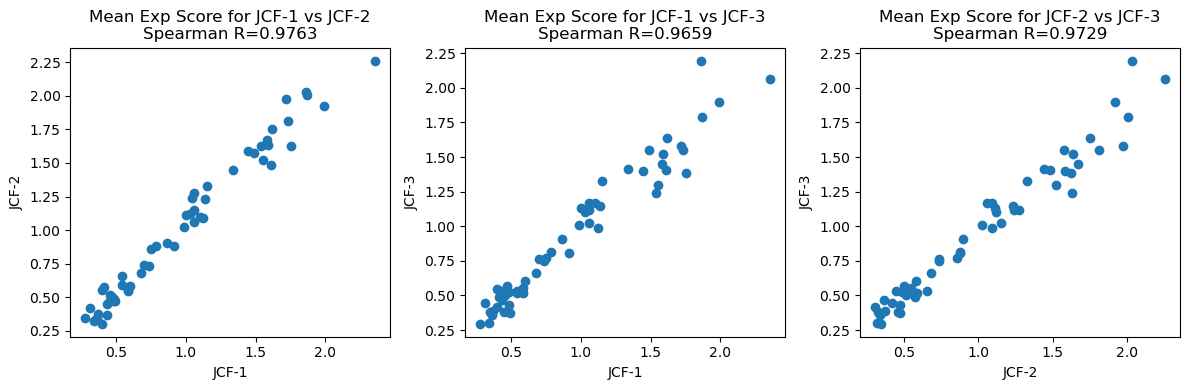

In [32]:
from itertools import combinations
from scipy.stats import spearmanr

dff = adata.obs[['sample']].join(exp_all).groupby('sample', observed=True).mean().T
fig, axes = plt.subplots(1, 3, figsize=(12, 4))
sample_pairs = list(combinations(dff.columns.unique().tolist(), 2))

for ax, (x_sample, y_sample) in zip(axes, sample_pairs):
    x = dff[x_sample]
    y = dff[y_sample]
    
    # Compute Pearson correlation
    # use spearman R here because we do not assumen normal distribution of enhancer expression
    corr, _ = spearmanr(x, y)
    
    ax.scatter(x, y)
    ax.set_xlabel(x_sample)
    ax.set_ylabel(y_sample)
    ax.set_title(f'Mean Exp Score for {x_sample} vs {y_sample}\nSpearman R={corr:.4f}')

plt.tight_layout()
plt.savefig('../6-grammar_final/figs/fig30a_qc_mean.svg', format="svg")
plt.show()

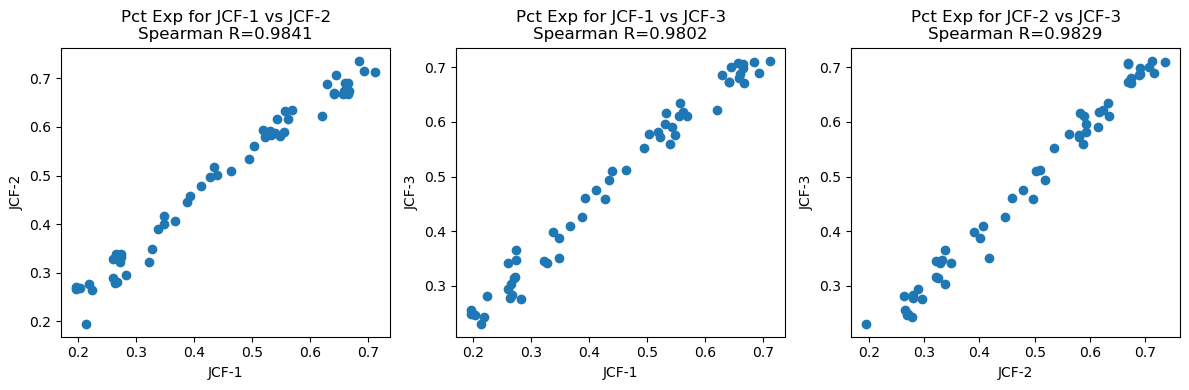

In [17]:
dff = adata.obs[['sample']].join(exp_all).groupby('sample', observed=True).apply(lambda g: (g > 0).sum() / g.notna().sum()).T
fig, axes = plt.subplots(1, 3, figsize=(12, 4))
sample_pairs = list(combinations(dff.columns.unique().tolist(), 2))

for ax, (x_sample, y_sample) in zip(axes, sample_pairs):
    x = dff[x_sample]
    y = dff[y_sample]
    
    # Compute Pearson correlation
    # use spearman R here because we do not assumen normal distribution of enhancer expression
    corr, _ = spearmanr(x, y)
    
    ax.scatter(x, y)
    ax.set_xlabel(x_sample)
    ax.set_ylabel(y_sample)
    ax.set_title(f'Pct Exp for {x_sample} vs {y_sample}\nSpearman R={corr:.4f}')

plt.tight_layout()
plt.savefig('../6-grammar_final/figs/fig30b_qc_pct.svg', format="svg")
plt.show()

# Setting up exp threshold

In the reporter assay, the promoter alone is able to drive some baseline expression. We'd like to determine a cutoff to eliminate that baseline expression.

Given microscopy data, we know three inert sequences that did not drive expression. We would use those to set up the baseline cutoff.

In [34]:
flattened = exp_all[['ORL30', 'ORL31', 'ORL32']].values.flatten()
inert = flattened[~np.isnan(flattened)]

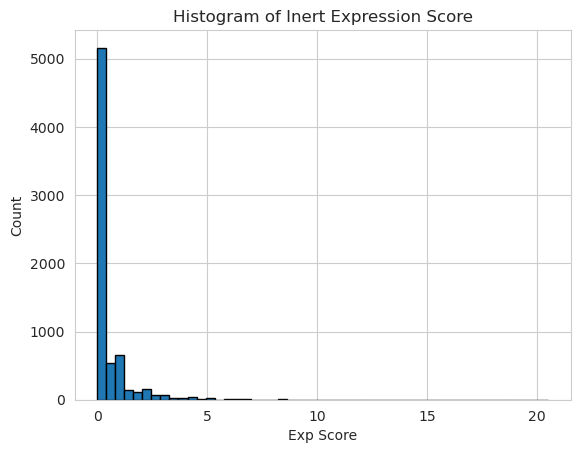

In [35]:
# Take a look at the expression score distribution first: as expected, most of them have very low expression
plt.hist(inert, bins=50, edgecolor='black')
plt.xlabel('Exp Score')
plt.ylabel('Count')
plt.title('Histogram of Inert Expression Score')
plt.show()

In [36]:
# Use 95% as cutoff
cutoff = np.percentile(inert, 95)
cutoff

2.280427335016228

Now given the cutoff, I would mask any expression score below this cutoff as 0.

In [37]:
exp_all = exp_all.where((exp_all.isna()) | (exp_all > cutoff), 0)

# Merging with mRNA Data

In [18]:
# convert exp_all matrix to an annData object
edata = ad.AnnData(exp_all)

In [19]:
edata.raw = edata.copy()

In [20]:
del adata.varm

In [21]:
# merge the edata (enhancer expression) with adata (mRNA expression)
mdata = ad.concat([adata, edata], axis=1, join="outer", merge="first")

In [22]:
mdata

AnnData object with n_obs × n_vars = 16929 × 15006
    obs: 'sample', 'n_genes_by_counts', 'total_counts', 'total_counts_mt', 'pct_counts_mt', 'n_genes', 'n_counts', 'doublet_score', 'predicted_doublet', 'leiden_res0_25', 'leiden_res0_5', 'leiden_res1', 'leiden_res3', 'celltype', 'updated_label', 'col_celltype', 'cellBC'
    var: 'mt', 'n_cells_by_counts', 'mean_counts', 'pct_dropout_by_counts', 'total_counts', 'n_cells', 'KH', 'Unique name (used in some papers)', 'Human homolog', 'Gene Name', 'highly_variable', 'means', 'dispersions', 'dispersions_norm', 'highly_variable_nbatches', 'highly_variable_intersection', 'mean', 'std'
    obsm: 'X_pca', 'X_umap'
    obsp: 'connectivities', 'distances'

# Visualization tested enhancers by dotplot

In [43]:
exp_all = exp_all.merge(adata.obs[['col_celltype']], left_index = True, right_index = True, how = 'left')

In [24]:
dot_color = exp_all.groupby('col_celltype', observed=True).mean()
dot_color = dot_color.fillna(0)
dot_size = exp_all.groupby('col_celltype', observed=True).apply(lambda g: (g > 0).sum() / g.notna().sum())

In [25]:
# reorder the enhancers by increasing expression in a6.5
a_enh_order = dot_color.T['a6.5'].sort_values().index.to_list()
lookup = lookup.set_index('enhancer_id').loc[a_enh_order].reset_index()

In [26]:
# make the dict for test enhancers
selected_enhancers = lookup[lookup['label_test'].isin(['inert test', 'moderate test', 'robust test'])][['bin-anno', 'enhancer_id']].drop_duplicates()
test_bin2eh = selected_enhancers.groupby('bin-anno').agg(list).to_dict()['enhancer_id']
test_bin2eh = {k: test_bin2eh[k] for k in ['Inert', 'Moderate', 'Robust']}

In [27]:
# make the dict for control enhancers
col_name = 'label_control'
selected_enhancers = lookup[lookup[col_name].notna()][[col_name, 'enhancer_id']].drop_duplicates()
control_bin2eh = selected_enhancers.groupby(col_name).agg(list).to_dict()['enhancer_id']
control_bin2eh = {k: control_bin2eh[k] for k in ['Inert Zero', 'Inert Residual', 'Neural', 'Ectopic']}

# Test Enhancers Plot

In [32]:
# Ready to plot
dotplot = sc.pl.dotplot(
    mdata,
    categories_order = ['b6.5','a6.5', 'a6.7 PSV','a6.7 ASV','Trunk Lateral Cell', 'Endoderm (A)','Primary Notochord',
                        'VNC + PSV','A-line ASV/PSV','LNC', 'Endoderm (B)','Secondary Notochord','Mesenchyme',
                        'Epidermis (a)','Epidermis (b)', 'Heart', 'Muscle A/B', 'Germ Cell'],
    groupby='col_celltype',
    var_names=test_bin2eh,
    return_fig = True,
    cmap = 'Greens',
    dot_max = 0.6
)

In [33]:
# Use custom dotcolor and dotsize, as the original dotplot function does not know how to deal with NA value
dotplot.dot_color_df = dot_color.loc[dotplot.dot_color_df.index, dotplot.dot_color_df.columns]
dotplot.dot_size_df = dot_size.loc[dotplot.dot_color_df.index, dotplot.dot_color_df.columns]

In [34]:
# Set up min dot threshold
dot_min = 0.15 

In [35]:
dotplot.dot_size_df = dotplot.dot_size_df.where(dotplot.dot_size_df>dot_min, 0)

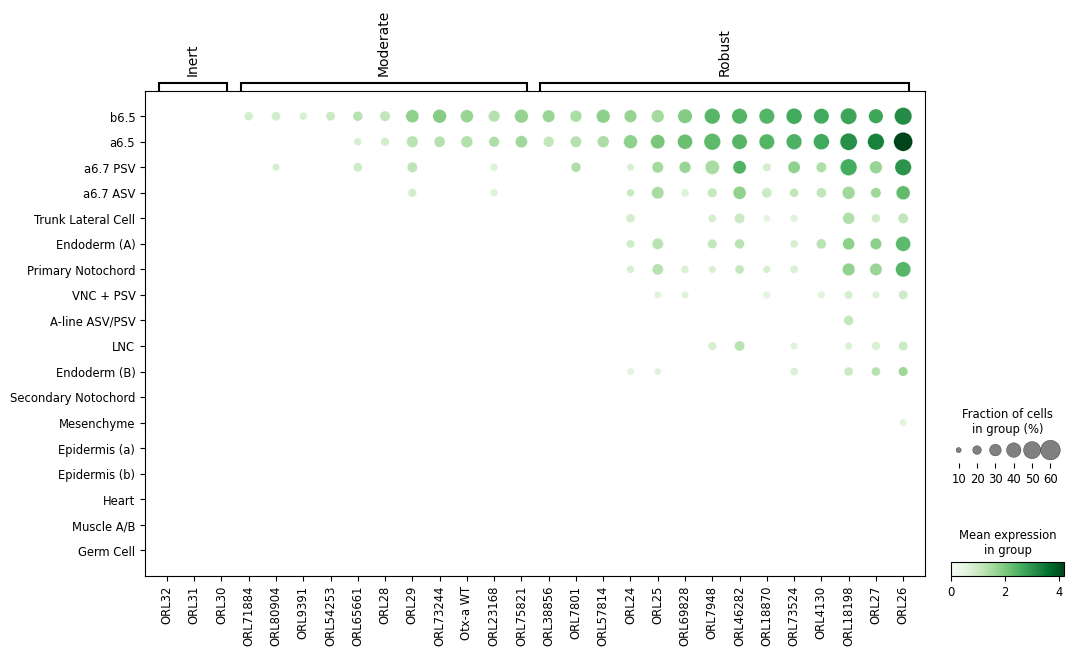

In [36]:
# make main figure 5
dotplot.dot_edge_color = 'white'
dotplot.savefig('../6-grammar_final/figs/test_enhancer_dotplot.svg', format="svg")

In [129]:
# also save the two dataframes
dot_color.to_csv('../6-grammar_final/supp/supp12_all_dotplot_color.csv')
dot_size.to_csv('../6-grammar_final/supp/supp12_all_dotplot_size.csv')

# Control Enhancers Plot

In [28]:
# Ready to plot
dotplot = sc.pl.dotplot(
    mdata,
    categories_order = ['b6.5','a6.5', 'a6.7 PSV','a6.7 ASV','Trunk Lateral Cell', 'Endoderm (A)','Primary Notochord',
                        'VNC + PSV','A-line ASV/PSV','LNC', 'Endoderm (B)','Secondary Notochord','Mesenchyme',
                        'Epidermis (a)','Epidermis (b)', 'Heart', 'Muscle A/B', 'Germ Cell'],
    groupby='col_celltype',
    var_names=control_bin2eh,
    return_fig = True,
    cmap = 'Greens',
    dot_max = 0.6
)

In [29]:
# Use custom dotcolor and dotsize, as the original dotplot function does not know how to deal with NA value
dotplot.dot_color_df = dot_color.loc[dotplot.dot_color_df.index, dotplot.dot_color_df.columns]
dotplot.dot_size_df = dot_size.loc[dotplot.dot_color_df.index, dotplot.dot_color_df.columns]

In [30]:
# Set up min dot threshold
dot_min = 0.15 

In [31]:
dotplot.dot_size_df = dotplot.dot_size_df.where(dotplot.dot_size_df>dot_min, 0)

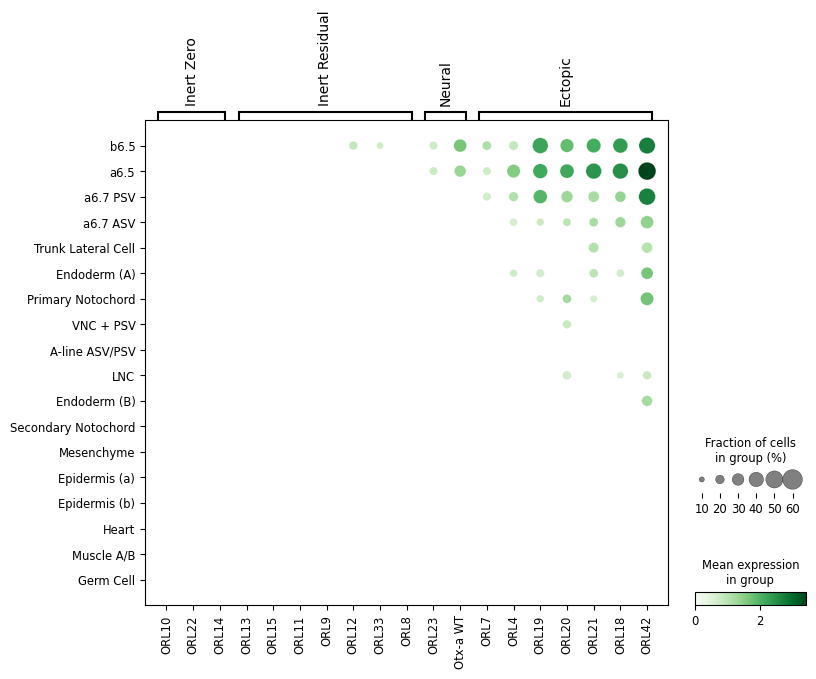

In [32]:
# make supp figure 29
dotplot.dot_edge_color = 'white'
dotplot.savefig('../6-grammar_final/figs/control_enhancer_dotplot.svg', format="svg")

# Visualize all enhancers

In [136]:
lookup['syntax-score'] = lookup['syntax-score'].astype(str)
lookup['num-syntax-motifs'] = lookup['num-syntax-motifs'].astype(str)

In [137]:
# make the dict for syntax score
order_by = 'syntax-score'
score_bin2eh = lookup[[order_by, 'enhancer_id']].drop_duplicates().groupby(order_by).agg(list).to_dict()['enhancer_id']
score_bin2eh = {k: score_bin2eh[k] for k in sorted(score_bin2eh, key=lambda x: int(x))}

In [138]:
# make the dict for number of syntax motifs
order_by = 'num-syntax-motifs' 
num_bin2eh = lookup[[order_by, 'enhancer_id']].drop_duplicates().groupby(order_by).agg(list).to_dict()['enhancer_id']
num_bin2eh = {k: num_bin2eh[k] for k in sorted(num_bin2eh, key=lambda x: int(x))}

In [139]:
# Ready to plot
dotplot = sc.pl.dotplot(
    mdata,
    categories_order = ['b6.5','a6.5', 'a6.7 PSV','a6.7 ASV','Trunk Lateral Cell', 'Endoderm (A)','Primary Notochord',
                        'VNC + PSV','A-line ASV/PSV','LNC', 'Endoderm (B)','Secondary Notochord','Mesenchyme',
                        'Epidermis (a)','Epidermis (b)', 'Heart', 'Muscle A/B', 'Germ Cell'],
    groupby='col_celltype',
    var_names=score_bin2eh,
    return_fig = True,
    cmap = 'Greens',
    dot_max = 0.6
)

In [140]:
# Use custom dotcolor and dotsize, as the original dotplot function does not know how to deal with NA value
dotplot.dot_color_df = dot_color.loc[dotplot.dot_color_df.index, dotplot.dot_color_df.columns]
dotplot.dot_size_df = dot_size.loc[dotplot.dot_color_df.index, dotplot.dot_color_df.columns]

In [141]:
dot_min = 0.15

In [142]:
dotplot.dot_size_df = dotplot.dot_size_df.where(dotplot.dot_size_df>dot_min, 0)

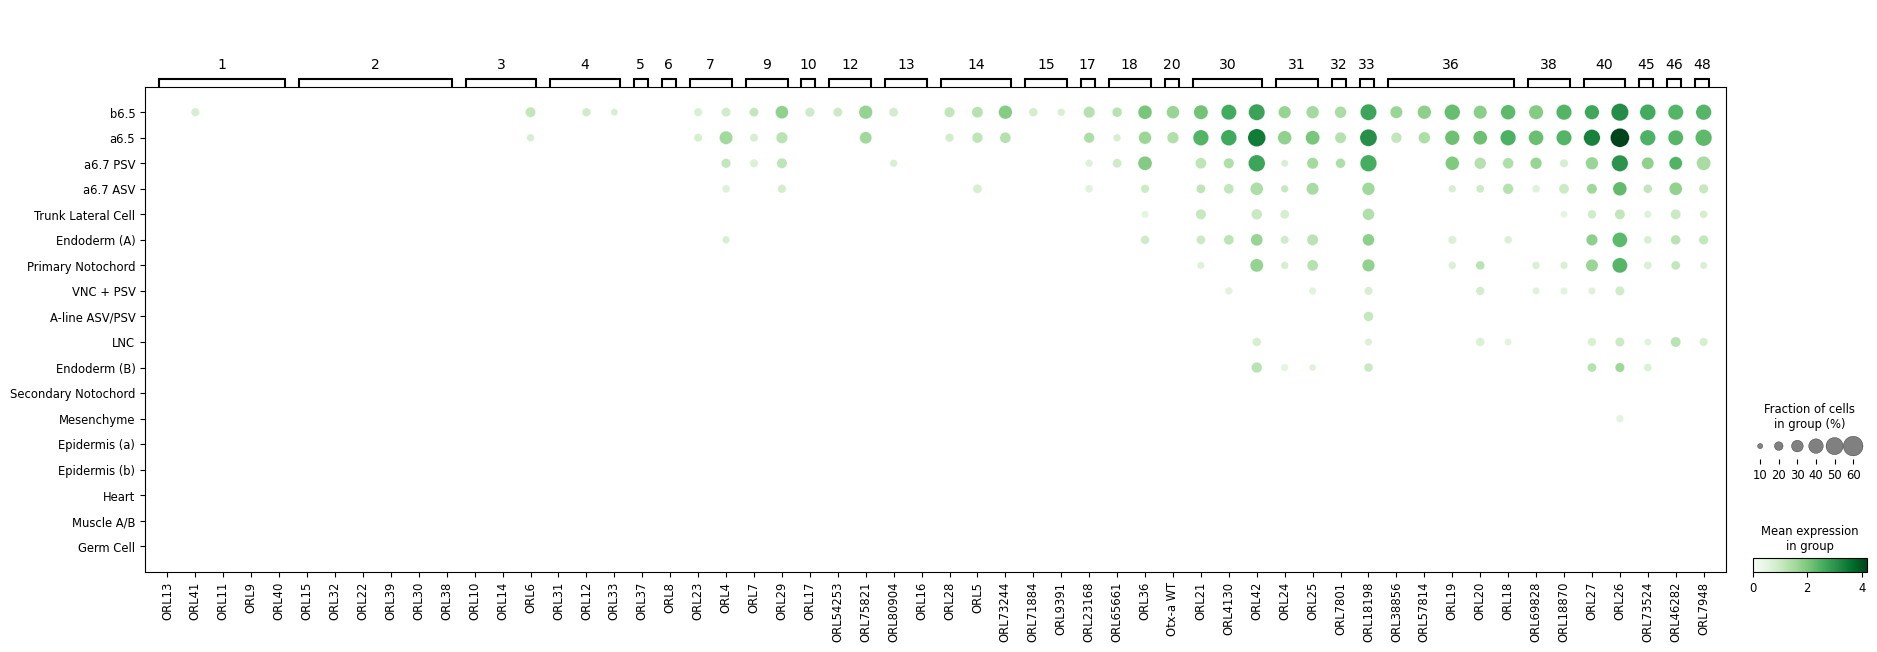

In [143]:
dotplot.dot_edge_color = 'white'
dotplot.savefig('../6-grammar_final/figs/fig35b_score_enhancer_dotplot.svg', format="svg")

In [144]:
# Ready to plot
dotplot = sc.pl.dotplot(
    mdata,
    categories_order = ['b6.5','a6.5', 'a6.7 PSV','a6.7 ASV','Trunk Lateral Cell', 'Endoderm (A)','Primary Notochord',
                        'VNC + PSV','A-line ASV/PSV','LNC', 'Endoderm (B)','Secondary Notochord','Mesenchyme',
                        'Epidermis (a)','Epidermis (b)', 'Heart', 'Muscle A/B', 'Germ Cell'],
    groupby='col_celltype',
    var_names=num_bin2eh,
    return_fig = True,
    cmap = 'Greens',
    dot_max = 0.6
)

In [145]:
# Use custom dotcolor and dotsize, as the original dotplot function does not know how to deal with NA value
dotplot.dot_color_df = dot_color.loc[dotplot.dot_color_df.index, dotplot.dot_color_df.columns]
dotplot.dot_size_df = dot_size.loc[dotplot.dot_color_df.index, dotplot.dot_color_df.columns]

In [146]:
# Set up min dot threshold using the three known inert sequence
dot_min = 0.15

In [147]:
dotplot.dot_size_df = dotplot.dot_size_df.where(dotplot.dot_size_df>dot_min, 0)

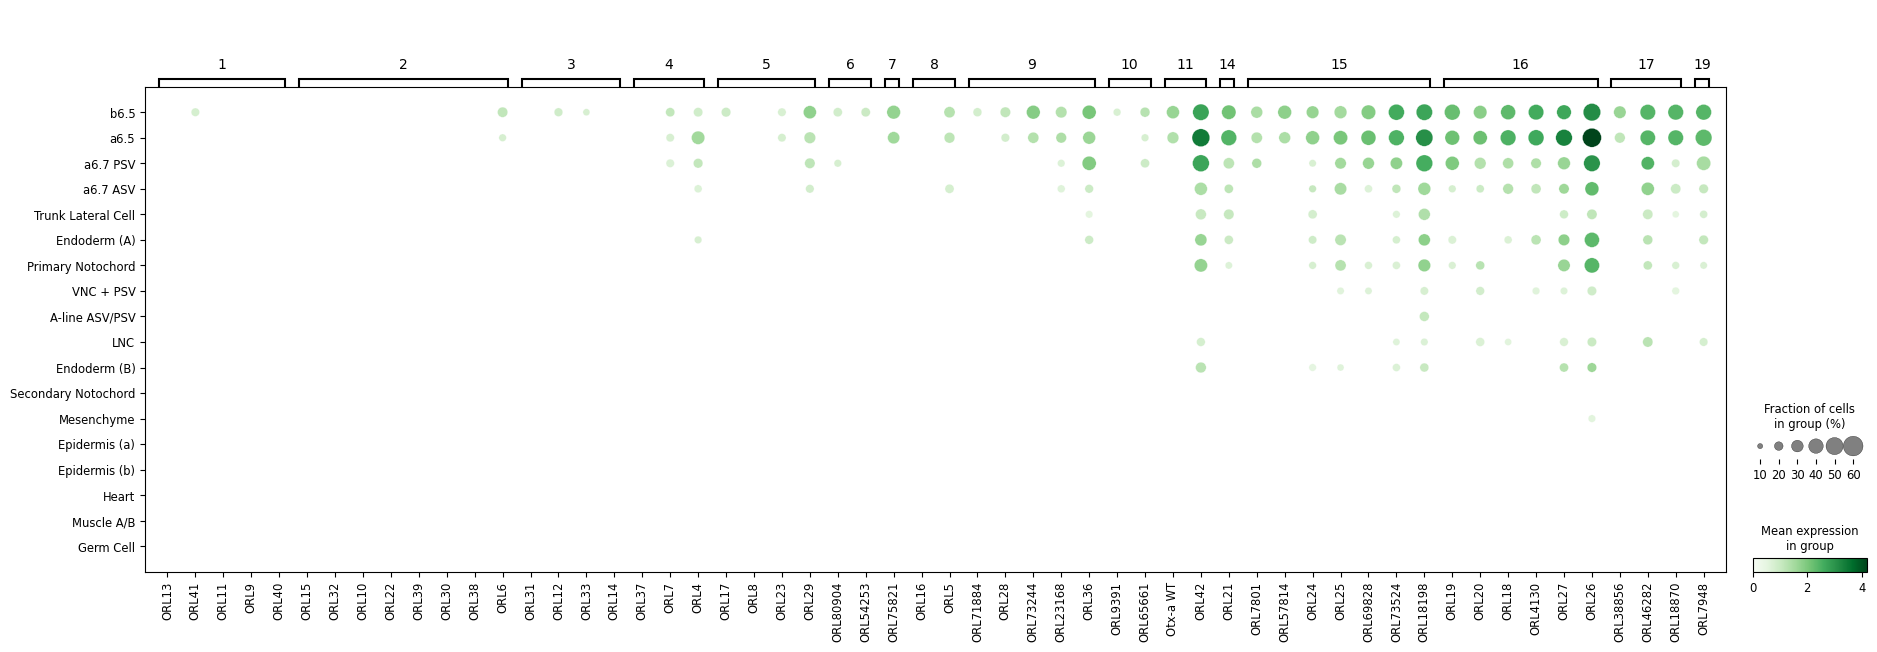

In [148]:
dotplot.dot_edge_color = 'white'
dotplot.savefig('../6-grammar_final/figs/fig35a_num_enhancer_dotplot.svg', format="svg")

# Collapse on Celltype Lineage (make supp table 12)

In [149]:
exp_ectopic = exp_all[~exp_all['col_celltype'].isin(['Epidermis (a)', 'Epidermis (b)', 'Muscle A/B', 'Heart', 'Germ Cell'])]

In [150]:
exp_ectopic['col_celltype'].unique().tolist()

['a6.5',
 'Endoderm (A)',
 'Primary Notochord',
 'Trunk Lateral Cell',
 'Endoderm (B)',
 'Mesenchyme',
 'b6.5',
 'LNC',
 'VNC + PSV',
 'A-line ASV/PSV',
 'a6.7 ASV',
 'Secondary Notochord',
 'a6.7 PSV']

In [151]:
lineage_map = {
       'a6.5':'a6.5', 'Endoderm (A)':'A-line', 
       'Primary Notochord':'A-line', 'Trunk Lateral Cell':'A-line', 'Endoderm (B)':'B-line',
       'Mesenchyme':'B-line', 'b6.5':'b6.5', 'LNC':'A-line', 'VNC + PSV':'A-line', 'A-line ASV/PSV':'A-line', 
       'a6.7 ASV':'a6.7',
       'Secondary Notochord':'B-line', 'a6.7 PSV':'a6.7'
}

In [152]:
exp_ectopic['col_celltype'] = exp_ectopic['col_celltype'].map(lineage_map)

/scratch/qiw071/job_5599858/ipykernel_2672191/2464195030.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  exp_ectopic['col_celltype'] = exp_ectopic['col_celltype'].map(lineage_map)


In [153]:
dot_color = exp_ectopic.groupby('col_celltype', observed=True).mean()
dot_color = dot_color.fillna(0)
dot_size = exp_ectopic.groupby('col_celltype', observed=True).apply(lambda g: (g > 0).sum() / g.notna().sum())

In [155]:
dot_color

,ORL10,ORL11,ORL12,ORL13,ORL14,ORL15,ORL16,ORL17,ORL18,ORL18198,...,ORL73244,ORL73524,ORL75821,ORL7801,ORL7948,ORL8,ORL80904,ORL9,ORL9391,Otx-a WT
col_celltype,,,,,,,,,,,,,,,,,,,,,
A-line,0.071838,0.203940,0.145773,0.047528,0.118573,0.095936,0.055874,0.121054,0.520719,1.386279,...,0.449346,0.628691,0.175667,0.340043,0.786048,0.211713,0.112581,0.158809,0.232140,0.358646
B-line,0.037384,0.105418,0.128053,0.014852,0.017822,0.050366,0.145656,0.055129,0.272649,0.623804,...,0.172871,0.379379,0.126439,0.102657,0.337318,0.093909,0.083509,0.104608,0.059730,0.235966
a6.5,0.350372,0.313569,0.469829,0.300848,0.537140,0.308216,0.642690,0.456788,2.500062,3.075227,...,1.319885,2.482440,1.575136,1.319588,2.317437,0.514446,0.403744,0.377936,0.466056,1.355678
a6.7,0.125333,0.149934,0.310876,0.292661,0.224969,0.057733,0.097809,0.070755,1.331645,1.845656,...,0.513849,1.331984,0.415685,0.731510,1.180815,0.073384,0.212279,0.156211,0.154695,0.646330
b6.5,0.435601,0.581151,0.905694,0.354261,0.522374,0.253631,0.521792,0.956429,2.326936,2.718742,...,1.889150,2.608055,1.723063,1.448659,2.409153,0.480146,0.869468,0.684461,0.764315,1.682305


In [158]:
dot_color.to_csv('../6-grammar_final/supp/supp12_ectopic_all_dotplot_color.csv')
dot_size.to_csv('../6-grammar_final/supp/supp12_ectopic_all_dotplot_size.csv')